In [1]:
# Module 1: Load and prepare profile data for graph analysis
# This module loads shard files and creates a structured dataset

import xarray as xr
import numpy as np
import pandas as pd
from pathlib import Path
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

def get_input_with_default(prompt, default):
    """Get user input with default value."""
    response = input(f"{prompt} ").strip()
    return response if response else str(default)

# Configuration
SENSORS = ['temperature', 'salinity', 'density', 'dissolvedoxygen', 'cdom', 'chlora', 'backscatter']
STANDARD_DEPTHS = np.linspace(0, 180, 91)  # 2m resolution

# Get year range
start_year = int(get_input_with_default("Start year (default 2018):", "2018"))
end_year = int(get_input_with_default("End year (default 2018):", "2018"))

print(f"\nLoading profile data from {start_year} to {end_year}...")

# Collect all profile files
all_profiles = {}
for sensor in SENSORS:
    profile_files = []
    for year in range(start_year, end_year + 1):
        redux_dir = Path(f"~/redux{year}").expanduser()
        if redux_dir.exists():
            year_files = sorted(list(redux_dir.glob(f"*_{sensor}_*.nc")))
            profile_files.extend(year_files)
    all_profiles[sensor] = profile_files
    print(f"  {sensor}: {len(profile_files)} files")

# Use temperature as reference (most complete)
reference_files = all_profiles['temperature']
n_profiles = len(reference_files)

print(f"\nTotal profiles to process: {n_profiles}")

# Extract profile metadata
def extract_profile_metadata(filename):
    """Extract metadata from filename."""
    parts = filename.stem.split('_')
    year = int(parts[4])
    doy = int(parts[5])
    profile_idx = int(parts[6])
    profile_num = int(parts[7])
    
    # Convert to datetime
    date = datetime(year, 1, 1) + pd.Timedelta(days=doy - 1)
    
    return {
        'year': year,
        'doy': doy,
        'profile_idx': profile_idx,
        'profile_num': profile_num,
        'date': date
    }

# Build profile index
print("\nBuilding profile index...")
profile_metadata = []
for i, ref_file in enumerate(reference_files):
    if (i + 1) % 500 == 0:
        print(f"  Processed {i + 1}/{n_profiles}")
    metadata = extract_profile_metadata(ref_file)
    metadata['index'] = i
    profile_metadata.append(metadata)

profile_index = pd.DataFrame(profile_metadata)
print(f"\nProfile index created: {len(profile_index)} profiles")
print(f"Date range: {profile_index['date'].min()} to {profile_index['date'].max()}")

# Save for later use
profile_index.to_csv('profile_index.csv', index=False)
print("\nProfile index saved to profile_index.csv")


StdinNotImplementedError: raw_input was called, but this frontend does not support input requests.

In [13]:
# Module 2: Interpolate profiles to standard depth grid
# Creates feature vectors for each profile

import xarray as xr
import numpy as np
import pandas as pd
from pathlib import Path
import pickle

# Load profile index
profile_index = pd.read_csv('profile_index.csv')
profile_index['date'] = pd.to_datetime(profile_index['date'])

# Configuration
SENSORS = ['temperature', 'salinity', 'density', 'dissolvedoxygen', 'cdom', 'chlora', 'backscatter']
STANDARD_DEPTHS = np.linspace(0, 180, 91)  # 2m resolution
start_year = profile_index['year'].min()
end_year = profile_index['year'].max()

print(f"Interpolating {len(profile_index)} profiles to standard depth grid...")
print(f"Standard depths: {len(STANDARD_DEPTHS)} levels (0-180m, 2m resolution)")

# Collect profile files by sensor
all_profiles = {}
for sensor in SENSORS:
    profile_files = []
    for year in range(start_year, end_year + 1):
        redux_dir = Path(f"~/redux{year}").expanduser()
        if redux_dir.exists():
            year_files = sorted(list(redux_dir.glob(f"*_{sensor}_*.nc")))
            profile_files.extend(year_files)
    all_profiles[sensor] = profile_files

def interpolate_profile(filepath, sensor_name, standard_depths):
    """Interpolate a single profile to standard depth grid."""
    try:
        ds = xr.open_dataset(filepath)
        sensor_data = ds[sensor_name].values
        depth = ds['depth'].values
        
        # Remove NaN values
        valid_mask = ~(np.isnan(sensor_data) | np.isnan(depth))
        if not np.any(valid_mask) or len(depth[valid_mask]) < 2:
            return np.full(len(standard_depths), np.nan)
        
        depth_clean = depth[valid_mask]
        data_clean = sensor_data[valid_mask]
        
        # Sort by depth
        sort_idx = np.argsort(depth_clean)
        depth_sorted = depth_clean[sort_idx]
        data_sorted = data_clean[sort_idx]
        
        # Interpolate to standard depths
        interp_data = np.interp(standard_depths, depth_sorted, data_sorted, 
                               left=np.nan, right=np.nan)
        
        return interp_data
        
    except Exception as e:
        return np.full(len(standard_depths), np.nan)

# Create feature matrix
# Shape: (n_profiles, n_sensors * n_depths)
n_profiles = len(profile_index)
n_features = len(SENSORS) * len(STANDARD_DEPTHS)

feature_matrix = np.zeros((n_profiles, n_features))
feature_names = []

# Build feature names
for sensor in SENSORS:
    for depth in STANDARD_DEPTHS:
        feature_names.append(f"{sensor}_{depth:.0f}m")

print(f"\nFeature matrix shape: {feature_matrix.shape}")
print(f"Features per profile: {n_features}")

# Interpolate all profiles
print("\nInterpolating profiles...")
for sensor_idx, sensor in enumerate(SENSORS):
    print(f"\n  Processing {sensor}...")
    sensor_files = all_profiles[sensor]
    
    for profile_idx in range(n_profiles):
        if (profile_idx + 1) % 500 == 0:
            print(f"    Profile {profile_idx + 1}/{n_profiles}")
        
        if profile_idx < len(sensor_files):
            interp_data = interpolate_profile(sensor_files[profile_idx], sensor, STANDARD_DEPTHS)
            
            # Store in feature matrix
            start_col = sensor_idx * len(STANDARD_DEPTHS)
            end_col = start_col + len(STANDARD_DEPTHS)
            feature_matrix[profile_idx, start_col:end_col] = interp_data

# Calculate completeness statistics
print("\n=== Data Completeness ===")
for sensor_idx, sensor in enumerate(SENSORS):
    start_col = sensor_idx * len(STANDARD_DEPTHS)
    end_col = start_col + len(STANDARD_DEPTHS)
    sensor_data = feature_matrix[:, start_col:end_col]
    
    completeness = np.sum(~np.isnan(sensor_data)) / sensor_data.size * 100
    print(f"{sensor}: {completeness:.1f}% complete")

# Overall completeness
overall_completeness = np.sum(~np.isnan(feature_matrix)) / feature_matrix.size * 100
print(f"\nOverall: {overall_completeness:.1f}% complete")

# Count profiles with at least 50% data
profile_completeness = np.sum(~np.isnan(feature_matrix), axis=1) / n_features
good_profiles = np.sum(profile_completeness >= 0.5)
print(f"\nProfiles with ≥50% data: {good_profiles}/{n_profiles} ({good_profiles/n_profiles*100:.1f}%)")

# Save feature matrix
print("\nSaving feature matrix...")
np.save('feature_matrix.npy', feature_matrix)
with open('feature_names.pkl', 'wb') as f:
    pickle.dump(feature_names, f)

print("Feature matrix saved to feature_matrix.npy")
print("Feature names saved to feature_names.pkl")


Interpolating 8316 profiles to standard depth grid...
Standard depths: 91 levels (0-180m, 2m resolution)

Feature matrix shape: (8316, 637)
Features per profile: 637

Interpolating profiles...

  Processing temperature...
    Profile 500/8316
    Profile 1000/8316
    Profile 1500/8316
    Profile 2000/8316
    Profile 2500/8316
    Profile 3000/8316
    Profile 3500/8316
    Profile 4000/8316
    Profile 4500/8316
    Profile 5000/8316
    Profile 5500/8316
    Profile 6000/8316
    Profile 6500/8316
    Profile 7000/8316
    Profile 7500/8316
    Profile 8000/8316

  Processing salinity...
    Profile 500/8316
    Profile 1000/8316
    Profile 1500/8316
    Profile 2000/8316
    Profile 2500/8316
    Profile 3000/8316
    Profile 3500/8316
    Profile 4000/8316
    Profile 4500/8316
    Profile 5000/8316
    Profile 5500/8316
    Profile 6000/8316
    Profile 6500/8316
    Profile 7000/8316
    Profile 7500/8316
    Profile 8000/8316

  Processing density...
    Profile 500/8316
    

In [14]:
# Module 3: Normalize features and handle missing data
# Prepares data for similarity computation

import numpy as np
import pandas as pd
import pickle
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Load data
print("Loading feature matrix...")
feature_matrix = np.load('feature_matrix.npy')
profile_index = pd.read_csv('profile_index.csv')
profile_index['date'] = pd.to_datetime(profile_index['date'])

with open('feature_names.pkl', 'rb') as f:
    feature_names = pickle.load(f)

print(f"Feature matrix shape: {feature_matrix.shape}")
print(f"Profiles: {len(profile_index)}")

# Strategy for missing data
print("\n=== Missing Data Strategy ===")
print("Options:")
print("  1. Remove profiles with >50% missing data")
print("  2. Impute missing values (mean imputation)")
print("  3. Use only complete profiles")

strategy = input("Select strategy (1/2/3, default 1): ").strip() or "1"

if strategy == "1":
    # Remove profiles with too much missing data
    profile_completeness = np.sum(~np.isnan(feature_matrix), axis=1) / feature_matrix.shape[1]
    good_mask = profile_completeness >= 0.5
    
    feature_matrix_clean = feature_matrix[good_mask]
    profile_index_clean = profile_index[good_mask].reset_index(drop=True)
    
    print(f"\nRemoved {np.sum(~good_mask)} profiles with >50% missing data")
    print(f"Remaining profiles: {len(profile_index_clean)}")
    
    # Impute remaining missing values with column mean
    imputer = SimpleImputer(strategy='mean')
    feature_matrix_imputed = imputer.fit_transform(feature_matrix_clean)
    
elif strategy == "2":
    # Impute all missing values
    imputer = SimpleImputer(strategy='mean')
    feature_matrix_imputed = imputer.fit_transform(feature_matrix)
    profile_index_clean = profile_index.copy()
    
    print(f"\nImputed all missing values")
    print(f"Profiles: {len(profile_index_clean)}")
    
elif strategy == "3":
    # Use only complete profiles
    complete_mask = ~np.any(np.isnan(feature_matrix), axis=1)
    
    feature_matrix_imputed = feature_matrix[complete_mask]
    profile_index_clean = profile_index[complete_mask].reset_index(drop=True)
    
    print(f"\nRemoved {np.sum(~complete_mask)} incomplete profiles")
    print(f"Remaining profiles: {len(profile_index_clean)}")

# Normalize features (z-score normalization)
print("\n=== Feature Normalization ===")
print("Applying z-score normalization (mean=0, std=1)...")

scaler = StandardScaler()
feature_matrix_normalized = scaler.fit_transform(feature_matrix_imputed)

print(f"Normalized feature matrix shape: {feature_matrix_normalized.shape}")

# Verify normalization
print("\nVerification:")
print(f"  Mean: {np.mean(feature_matrix_normalized):.6f} (should be ~0)")
print(f"  Std: {np.std(feature_matrix_normalized):.6f} (should be ~1)")

# Save processed data
print("\nSaving processed data...")
np.save('feature_matrix_normalized.npy', feature_matrix_normalized)
profile_index_clean.to_csv('profile_index_clean.csv', index=False)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("\nSaved:")
print("  - feature_matrix_normalized.npy")
print("  - profile_index_clean.csv")
print("  - scaler.pkl")

# Summary statistics
print("\n=== Summary ===")
print(f"Final dataset: {feature_matrix_normalized.shape[0]} profiles × {feature_matrix_normalized.shape[1]} features")
print(f"Date range: {profile_index_clean['date'].min()} to {profile_index_clean['date'].max()}")
print(f"Time span: {(profile_index_clean['date'].max() - profile_index_clean['date'].min()).days} days")


Loading feature matrix...
Feature matrix shape: (8316, 637)
Profiles: 8316

=== Missing Data Strategy ===
Options:
  1. Remove profiles with >50% missing data
  2. Impute missing values (mean imputation)
  3. Use only complete profiles


Select strategy (1/2/3, default 1):  



Removed 31 profiles with >50% missing data
Remaining profiles: 8285

=== Feature Normalization ===
Applying z-score normalization (mean=0, std=1)...
Normalized feature matrix shape: (8285, 637)

Verification:
  Mean: 0.000000 (should be ~0)
  Std: 0.988950 (should be ~1)

Saving processed data...

Saved:
  - feature_matrix_normalized.npy
  - profile_index_clean.csv
  - scaler.pkl

=== Summary ===
Final dataset: 8285 profiles × 637 features
Date range: 2016-01-01 00:00:00 to 2019-09-27 00:00:00
Time span: 1365 days


In [15]:
# Module 4: Build Depth-Time Similarity Graph
# Constructs weighted graph based on profile similarity

import numpy as np
import pandas as pd
import networkx as nx
from scipy.spatial.distance import pdist, squareform
from scipy.sparse import csr_matrix
import pickle

# Load normalized data
print("Loading normalized feature matrix...")
feature_matrix = np.load('feature_matrix_normalized.npy')
profile_index = pd.read_csv('profile_index_clean.csv')
profile_index['date'] = pd.to_datetime(profile_index['date'])

n_profiles = feature_matrix.shape[0]
print(f"Profiles: {n_profiles}")

# Compute pairwise squared distances (skip sqrt - only d^2 is needed for Gaussian kernel)
print("\n=== Computing Pairwise Squared Distances ===")
print("This may take a few minutes for large datasets...")

sq_distances = pdist(feature_matrix, metric='sqeuclidean')
sq_distance_matrix = squareform(sq_distances)

print(f"Squared distance matrix shape: {sq_distance_matrix.shape}")
print(f"Squared distance range: [{sq_distance_matrix[sq_distance_matrix > 0].min():.2f}, {sq_distance_matrix.max():.2f}]")

# Convert squared distances to similarities using Gaussian kernel
# w_ij = exp(-d_ij^2 / (2 * sigma^2))  where sigma^2 = median squared distance
print("\n=== Converting to Similarities ===")

# Adaptive sigma^2: use median squared distance
# (equivalent to sigma = sqrt(median_distance), but computed directly without sqrt)
median_sq_distance = np.median(sq_distance_matrix[sq_distance_matrix > 0])
print(f"Median squared distance: {median_sq_distance:.2f}")
print(f"Equivalent sigma: {np.sqrt(median_sq_distance):.2f}")

# Sigma^2 options
print("\nSigma² (kernel width) options:")
print(f"  1. Median sq. distance: {median_sq_distance:.2f}")
print(f"  2. 0.25 × median (narrower): {0.25 * median_sq_distance:.2f}")
print(f"  3. 4.0 × median (wider): {4.0 * median_sq_distance:.2f}")
print("  4. Custom sigma value (will be squared)")

sigma_choice = input("Select sigma (1/2/3/4, default 1): ").strip() or "1"

if sigma_choice == "1":
    sigma_sq = median_sq_distance
elif sigma_choice == "2":
    sigma_sq = 0.25 * median_sq_distance
elif sigma_choice == "3":
    sigma_sq = 4.0 * median_sq_distance
elif sigma_choice == "4":
    sigma = float(input("Enter custom sigma value: "))
    sigma_sq = sigma ** 2

sigma = np.sqrt(sigma_sq)
print(f"\nUsing sigma = {sigma:.2f} (sigma² = {sigma_sq:.2f})")

# Gaussian kernel: w_ij = exp(-d_ij^2 / (2 * sigma^2))
similarity_matrix = np.exp(-sq_distance_matrix / (2 * sigma_sq))

# Set diagonal to 0 (no self-loops)
np.fill_diagonal(similarity_matrix, 0)

print(f"Similarity range: [{similarity_matrix[similarity_matrix > 0].min():.6f}, {similarity_matrix.max():.6f}]")

# Graph construction strategy
print("\n=== Graph Construction Strategy ===")
print("Options:")
print("  1. k-Nearest Neighbors (sparse, k edges per node)")
print("  2. Epsilon-ball (edges for similarity > threshold)")
print("  3. Full graph (all edges, may be large)")

graph_type = input("Select strategy (1/2/3, default 1): ").strip() or "1"

if graph_type == "1":
    # k-NN graph
    k = int(input("Enter k (default 10): ").strip() or "10")
    print(f"\nBuilding {k}-NN graph...")
    
    # For each node, keep only k nearest neighbors
    adjacency = np.zeros_like(similarity_matrix)
    for i in range(n_profiles):
        # Get k largest similarities (excluding self)
        top_k_indices = np.argsort(similarity_matrix[i])[-k:]
        adjacency[i, top_k_indices] = similarity_matrix[i, top_k_indices]
    
    # Make symmetric (if i->j, then j->i)
    adjacency = np.maximum(adjacency, adjacency.T)
    
    n_edges = np.sum(adjacency > 0) // 2
    print(f"Edges: {n_edges}")
    
elif graph_type == "2":
    # Epsilon-ball graph
    epsilon = float(input("Enter similarity threshold (0-1, default 0.1): ").strip() or "0.1")
    print(f"\nBuilding epsilon-ball graph (threshold={epsilon})...")
    
    adjacency = similarity_matrix.copy()
    adjacency[adjacency < epsilon] = 0
    
    n_edges = np.sum(adjacency > 0) // 2
    print(f"Edges: {n_edges}")
    
elif graph_type == "3":
    # Full graph
    print("\nBuilding full graph...")
    adjacency = similarity_matrix.copy()
    n_edges = np.sum(adjacency > 0) // 2
    print(f"Edges: {n_edges}")

# Create NetworkX graph
print("\nCreating NetworkX graph...")
G = nx.from_numpy_array(adjacency)

# Add node attributes
for i, row in profile_index.iterrows():
    G.nodes[i]['date'] = row['date']
    G.nodes[i]['year'] = row['year']
    G.nodes[i]['doy'] = row['doy']
    G.nodes[i]['profile_idx'] = row['profile_idx']

print(f"\nGraph statistics:")
print(f"  Nodes: {G.number_of_nodes()}")
print(f"  Edges: {G.number_of_edges()}")
print(f"  Density: {nx.density(G):.6f}")
print(f"  Connected: {nx.is_connected(G)}")

if not nx.is_connected(G):
    components = list(nx.connected_components(G))
    print(f"  Connected components: {len(components)}")
    print(f"  Largest component size: {len(max(components, key=len))}")

# Save graph and matrices
print("\nSaving graph and matrices...")
with open('similarity_graph.pkl', 'wb') as f:
    pickle.dump(G, f)
np.save('similarity_matrix.npy', similarity_matrix)
np.save('adjacency_matrix.npy', adjacency)

# Save metadata
metadata = {
    'n_profiles': n_profiles,
    'sigma': sigma,
    'sigma_sq': sigma_sq,
    'graph_type': graph_type,
    'n_edges': n_edges,
    'date_range': (profile_index['date'].min(), profile_index['date'].max())
}

with open('graph_metadata.pkl', 'wb') as f:
    pickle.dump(metadata, f)

print("\nSaved:")
print("  - similarity_graph.pkl")
print("  - similarity_matrix.npy")
print("  - adjacency_matrix.npy")
print("  - graph_metadata.pkl")


Loading normalized feature matrix...
Profiles: 8285

=== Computing Pairwise Squared Distances ===
This may take a few minutes for large datasets...
Squared distance matrix shape: (8285, 8285)
Squared distance range: [8.99, 122736.44]

=== Converting to Similarities ===
Median squared distance: 654.33
Equivalent sigma: 25.58

Sigma² (kernel width) options:
  1. Median sq. distance: 654.33
  2. 0.25 × median (narrower): 163.58
  3. 4.0 × median (wider): 2617.30
  4. Custom sigma value (will be squared)


Select sigma (1/2/3/4, default 1):  



Using sigma = 25.58 (sigma² = 654.33)
Similarity range: [0.000000, 0.993155]

=== Graph Construction Strategy ===
Options:
  1. k-Nearest Neighbors (sparse, k edges per node)
  2. Epsilon-ball (edges for similarity > threshold)
  3. Full graph (all edges, may be large)


Select strategy (1/2/3, default 1):  
Enter k (default 10):  



Building 10-NN graph...
Edges: 60623

Creating NetworkX graph...

Graph statistics:
  Nodes: 8285
  Edges: 60623
  Density: 0.001767
  Connected: True

Saving graph and matrices...

Saved:
  - similarity_graph.pkl
  - similarity_matrix.npy
  - adjacency_matrix.npy
  - graph_metadata.pkl


Loading similarity graph...
Graph: 8285 nodes, 60623 edges

=== Computing Graph Laplacian ===
Laplacian type:
  1. Unnormalized: L = D - A
  2. Symmetric normalized: L_sym = I - D^(-1/2) A D^(-1/2)
  3. Random walk: L_rw = I - D^(-1) A


Select Laplacian (1/2/3, default 2):  


Using Symmetric Normalized Laplacian
Laplacian shape: (8285, 8285)

=== Computing Eigenspectrum ===
Computing 50 smallest eigenvalues...

Eigenvalue range: [-0.000000, 0.033980]

=== Spectral Properties ===
Algebraic connectivity (λ₂): 0.000000
  Interpretation: Measures graph connectivity
  Higher values → better connected (well-mixed water column)

Spectral gap (λ₃ - λ₂): 0.000476
  Interpretation: Indicates cluster structure
  Large gap → distinct regimes exist

Effective dimensionality (90% energy): 48
  Interpretation: Number of fundamental modes


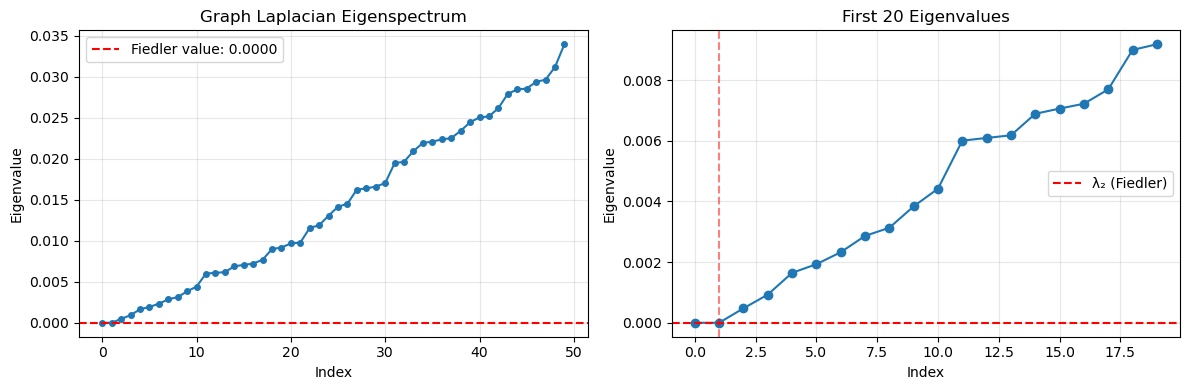


Eigenspectrum plot saved to eigenspectrum.png


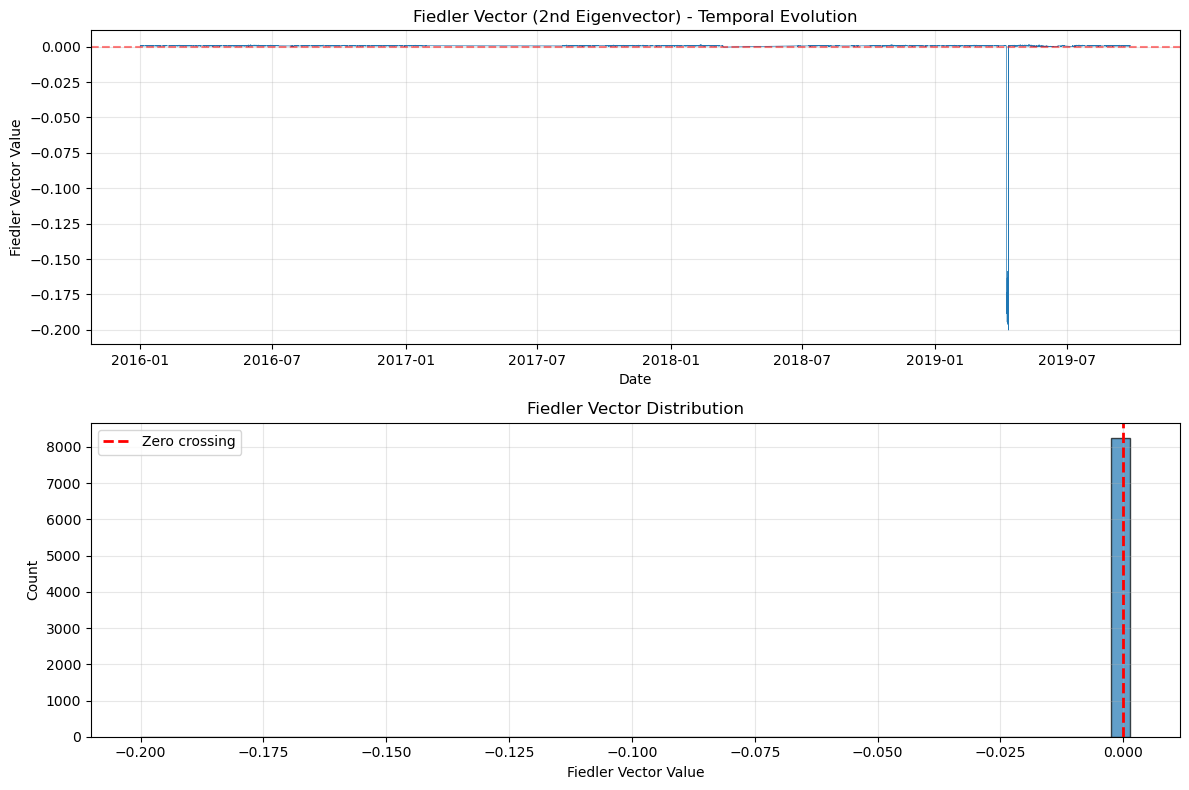

Fiedler vector plot saved to fiedler_vector.png

Saving spectral analysis results...

Saved:
  - eigenvalues.npy
  - eigenvectors.npy
  - spectral_properties.pkl
  - eigenspectrum.png
  - fiedler_vector.png

=== Analysis Complete ===
The Fiedler vector reveals natural partitioning of water column states.
Profiles with similar Fiedler values are dynamically similar.


In [16]:
# Module 5: Spectral Analysis of Similarity Graph
# Computes eigenvalues and eigenvectors of graph Laplacian

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from scipy.sparse.linalg import eigsh
import pickle

# Load graph
print("Loading similarity graph...")
with open('similarity_graph.pkl', 'rb') as f:
    G = pickle.load(f)
profile_index = pd.read_csv('profile_index_clean.csv')
profile_index['date'] = pd.to_datetime(profile_index['date'])

with open('graph_metadata.pkl', 'rb') as f:
    metadata = pickle.load(f)

print(f"Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

# Compute graph Laplacian
print("\n=== Computing Graph Laplacian ===")
print("Laplacian type:")
print("  1. Unnormalized: L = D - A")
print("  2. Symmetric normalized: L_sym = I - D^(-1/2) A D^(-1/2)")
print("  3. Random walk: L_rw = I - D^(-1) A")

laplacian_type = input("Select Laplacian (1/2/3, default 2): ").strip() or "2"

if laplacian_type == "1":
    L = nx.laplacian_matrix(G).astype(float)
    laplacian_name = "Unnormalized"
elif laplacian_type == "2":
    L = nx.normalized_laplacian_matrix(G).astype(float)
    laplacian_name = "Symmetric Normalized"
elif laplacian_type == "3":
    # Random walk Laplacian
    A = nx.adjacency_matrix(G).astype(float)
    D = np.array(A.sum(axis=1)).flatten()
    D_inv = np.diag(1.0 / D)
    L = np.eye(len(D)) - D_inv @ A.toarray()
    laplacian_name = "Random Walk"

print(f"Using {laplacian_name} Laplacian")
print(f"Laplacian shape: {L.shape}")

# Compute eigenvalues and eigenvectors
print("\n=== Computing Eigenspectrum ===")
n_eigenvalues = min(50, G.number_of_nodes() - 2)
print(f"Computing {n_eigenvalues} smallest eigenvalues...")

if laplacian_type in ["1", "2"]:
    # Use sparse eigensolver
    eigenvalues, eigenvectors = eigsh(L, k=n_eigenvalues, which='SM')
else:
    # Dense computation for random walk
    eigenvalues, eigenvectors = np.linalg.eigh(L)
    eigenvalues = eigenvalues[:n_eigenvalues]
    eigenvectors = eigenvectors[:, :n_eigenvalues]

# Sort by eigenvalue
sort_idx = np.argsort(eigenvalues)
eigenvalues = eigenvalues[sort_idx]
eigenvectors = eigenvectors[:, sort_idx]

print(f"\nEigenvalue range: [{eigenvalues[0]:.6f}, {eigenvalues[-1]:.6f}]")

# Key spectral properties
print("\n=== Spectral Properties ===")

# Algebraic connectivity (Fiedler value)
fiedler_value = eigenvalues[1]
print(f"Algebraic connectivity (λ₂): {fiedler_value:.6f}")
print("  Interpretation: Measures graph connectivity")
print("  Higher values → better connected (well-mixed water column)")

# Spectral gap
spectral_gap = eigenvalues[2] - eigenvalues[1]
print(f"\nSpectral gap (λ₃ - λ₂): {spectral_gap:.6f}")
print("  Interpretation: Indicates cluster structure")
print("  Large gap → distinct regimes exist")

# Effective dimensionality (90% of spectral energy)
cumulative_energy = np.cumsum(eigenvalues) / np.sum(eigenvalues)
effective_dim = np.searchsorted(cumulative_energy, 0.9) + 1
print(f"\nEffective dimensionality (90% energy): {effective_dim}")
print("  Interpretation: Number of fundamental modes")

# Plot eigenvalue spectrum
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Full spectrum
axes[0].plot(range(len(eigenvalues)), eigenvalues, 'o-', markersize=4)
axes[0].axhline(y=fiedler_value, color='r', linestyle='--', label=f'Fiedler value: {fiedler_value:.4f}')
axes[0].set_xlabel('Index')
axes[0].set_ylabel('Eigenvalue')
axes[0].set_title('Graph Laplacian Eigenspectrum')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# First 20 eigenvalues (zoomed)
n_plot = min(20, len(eigenvalues))
axes[1].plot(range(n_plot), eigenvalues[:n_plot], 'o-', markersize=6)
axes[1].axhline(y=fiedler_value, color='r', linestyle='--', label=f'λ₂ (Fiedler)')
axes[1].axvline(x=1, color='r', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Index')
axes[1].set_ylabel('Eigenvalue')
axes[1].set_title('First 20 Eigenvalues')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.savefig('eigenspectrum.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nEigenspectrum plot saved to eigenspectrum.png")

# Plot Fiedler vector (2nd eigenvector)
fiedler_vector = eigenvectors[:, 1]

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Fiedler vector vs time
axes[0].plot(profile_index['date'], fiedler_vector, '-', linewidth=0.5)
axes[0].axhline(y=0, color='r', linestyle='--', alpha=0.5)
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Fiedler Vector Value')
axes[0].set_title('Fiedler Vector (2nd Eigenvector) - Temporal Evolution')
axes[0].grid(True, alpha=0.3)

# Histogram of Fiedler vector
axes[1].hist(fiedler_vector, bins=50, edgecolor='black', alpha=0.7)
axes[1].axvline(x=0, color='r', linestyle='--', linewidth=2, label='Zero crossing')
axes[1].set_xlabel('Fiedler Vector Value')
axes[1].set_ylabel('Count')
axes[1].set_title('Fiedler Vector Distribution')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.savefig('fiedler_vector.png', dpi=150, bbox_inches='tight')
plt.show()

print("Fiedler vector plot saved to fiedler_vector.png")

# Save spectral data
print("\nSaving spectral analysis results...")
np.save('eigenvalues.npy', eigenvalues)
np.save('eigenvectors.npy', eigenvectors)

spectral_properties = {
    'laplacian_type': laplacian_name,
    'n_eigenvalues': len(eigenvalues),
    'fiedler_value': fiedler_value,
    'spectral_gap': spectral_gap,
    'effective_dimensionality': effective_dim,
    'eigenvalue_range': (eigenvalues[0], eigenvalues[-1])
}

with open('spectral_properties.pkl', 'wb') as f:
    pickle.dump(spectral_properties, f)

print("\nSaved:")
print("  - eigenvalues.npy")
print("  - eigenvectors.npy")
print("  - spectral_properties.pkl")
print("  - eigenspectrum.png")
print("  - fiedler_vector.png")

print("\n=== Analysis Complete ===")
print(f"The Fiedler vector reveals natural partitioning of water column states.")
print(f"Profiles with similar Fiedler values are dynamically similar.")


Loading spectral analysis results...
Profiles: 8285
Eigenvalues: 50

=== Determining Optimal Number of Clusters ===


Number of eigenvectors to use (default 10):  


Using first 10 eigenvectors

Evaluating cluster quality...
  k=2: Silhouette=0.781, Davies-Bouldin=0.231
  k=3: Silhouette=0.261, Davies-Bouldin=0.811
  k=4: Silhouette=0.293, Davies-Bouldin=0.769
  k=5: Silhouette=0.278, Davies-Bouldin=0.918
  k=6: Silhouette=0.379, Davies-Bouldin=0.859
  k=7: Silhouette=0.464, Davies-Bouldin=0.761
  k=8: Silhouette=0.499, Davies-Bouldin=0.695
  k=9: Silhouette=0.533, Davies-Bouldin=0.668
  k=10: Silhouette=0.572, Davies-Bouldin=0.579


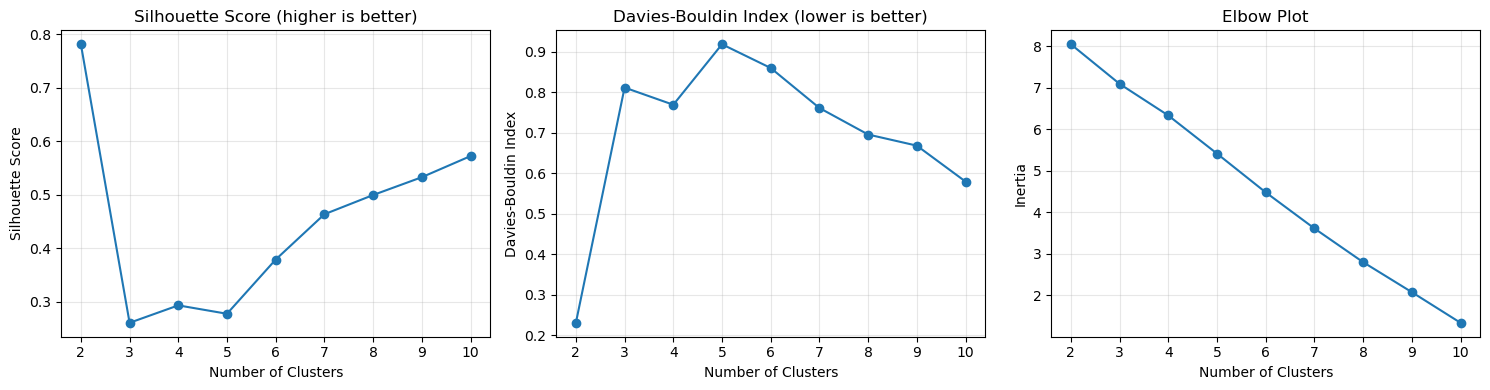


Cluster quality plot saved to cluster_quality.png

Recommended k (max silhouette): 2


Select number of clusters (default 2):  



=== Spectral Clustering with k=2 ===

Cluster sizes:
  Cluster 0: 8253 profiles (99.6%)
  Cluster 1: 32 profiles (0.4%)


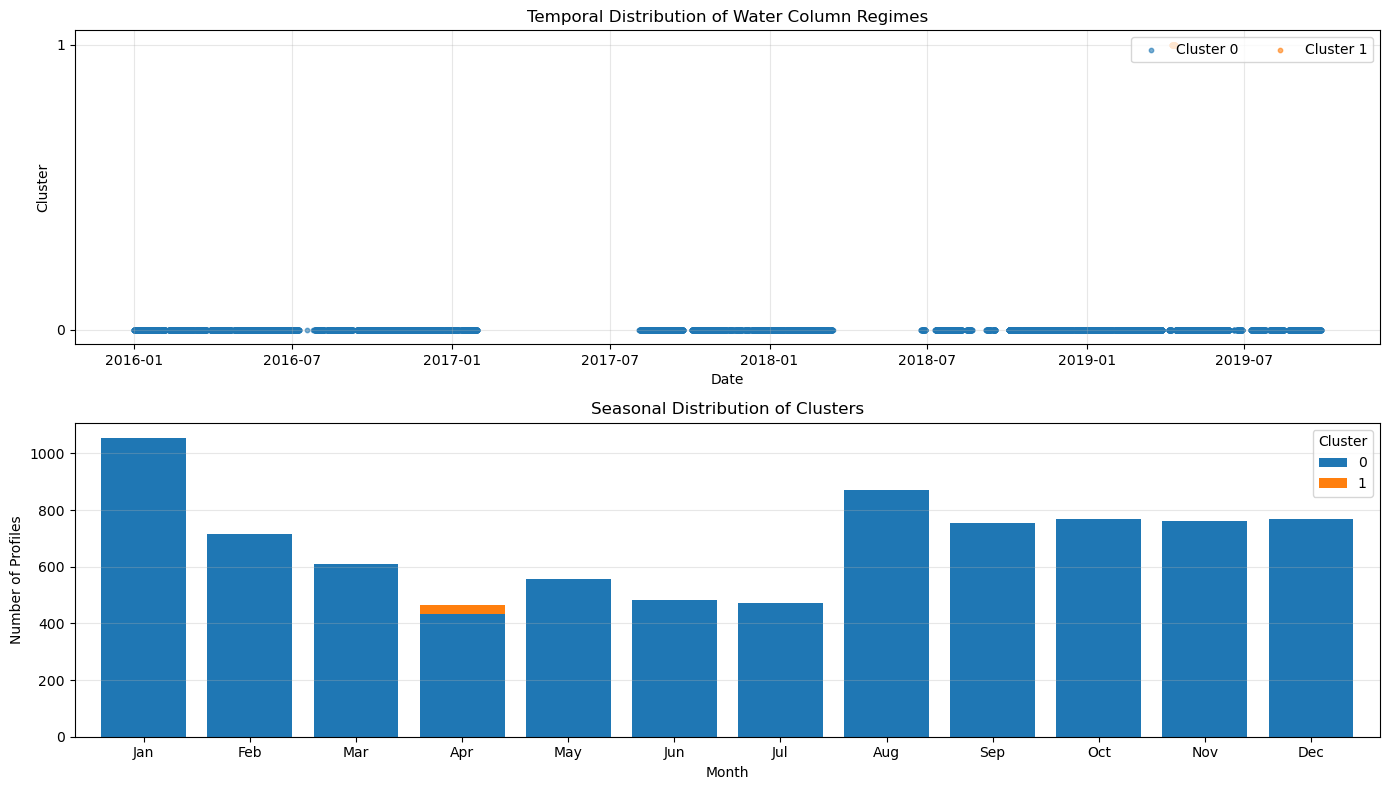


Cluster temporal distribution saved to cluster_temporal.png


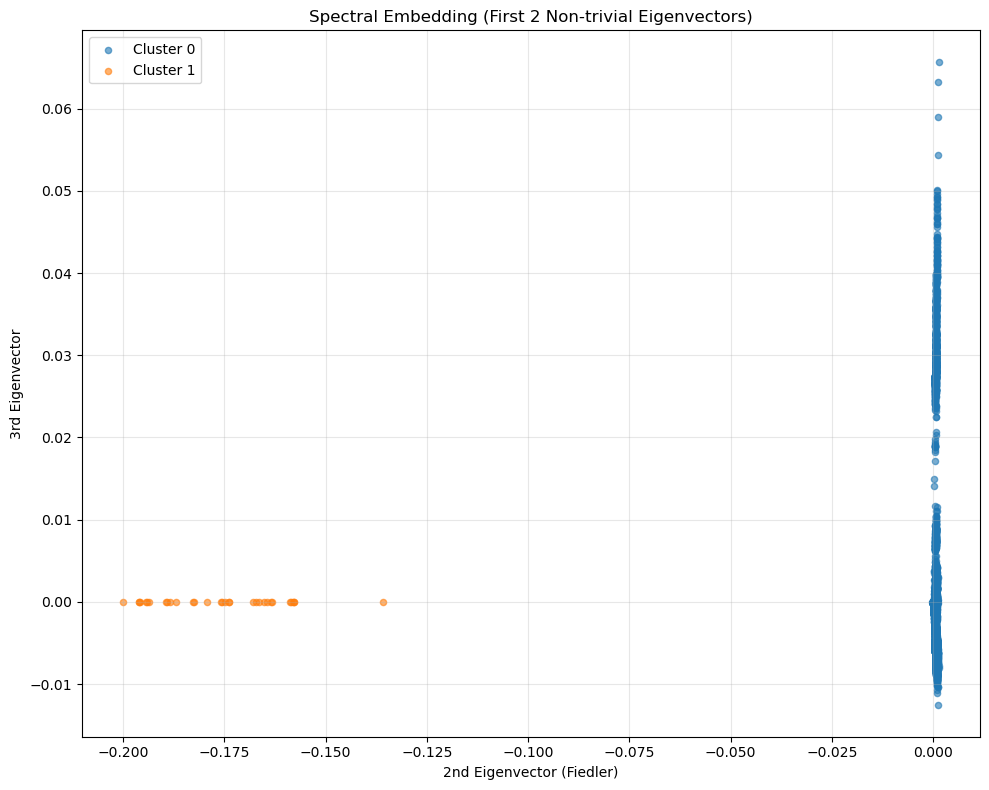

Spectral embedding plot saved to spectral_embedding.png

Saving clustering results...

Saved:
  - profile_index_clustered.csv
  - cluster_labels.npy
  - clustering_results.pkl
  - cluster_quality.png
  - cluster_temporal.png
  - spectral_embedding.png

=== Clustering Complete ===
Identified 2 distinct water column regimes
Next step: Characterize each cluster by examining representative profiles


In [17]:
# Module 6: Spectral Clustering
# Identifies water column regimes using spectral methods

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
import pickle

# Load spectral data
print("Loading spectral analysis results...")
eigenvalues = np.load('eigenvalues.npy')
eigenvectors = np.load('eigenvectors.npy')
profile_index = pd.read_csv('profile_index_clean.csv')
profile_index['date'] = pd.to_datetime(profile_index['date'])

with open('spectral_properties.pkl', 'rb') as f:
    spectral_props = pickle.load(f)

print(f"Profiles: {len(profile_index)}")
print(f"Eigenvalues: {len(eigenvalues)}")

# Determine optimal number of clusters
print("\n=== Determining Optimal Number of Clusters ===")

# Use first k eigenvectors for clustering
n_eigenvectors = int(input("Number of eigenvectors to use (default 10): ").strip() or "10")
n_eigenvectors = min(n_eigenvectors, eigenvectors.shape[1])

embedding = eigenvectors[:, :n_eigenvectors]
print(f"Using first {n_eigenvectors} eigenvectors")

# Test different numbers of clusters
k_range = range(2, 11)
silhouette_scores = []
davies_bouldin_scores = []
inertias = []

print("\nEvaluating cluster quality...")
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(embedding)
    
    silhouette = silhouette_score(embedding, labels)
    davies_bouldin = davies_bouldin_score(embedding, labels)
    
    silhouette_scores.append(silhouette)
    davies_bouldin_scores.append(davies_bouldin)
    inertias.append(kmeans.inertia_)
    
    print(f"  k={k}: Silhouette={silhouette:.3f}, Davies-Bouldin={davies_bouldin:.3f}")

# Plot cluster quality metrics
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(k_range, silhouette_scores, 'o-', markersize=6)
axes[0].set_xlabel('Number of Clusters')
axes[0].set_ylabel('Silhouette Score')
axes[0].set_title('Silhouette Score (higher is better)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(k_range, davies_bouldin_scores, 'o-', markersize=6)
axes[1].set_xlabel('Number of Clusters')
axes[1].set_ylabel('Davies-Bouldin Index')
axes[1].set_title('Davies-Bouldin Index (lower is better)')
axes[1].grid(True, alpha=0.3)

axes[2].plot(k_range, inertias, 'o-', markersize=6)
axes[2].set_xlabel('Number of Clusters')
axes[2].set_ylabel('Inertia')
axes[2].set_title('Elbow Plot')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('cluster_quality.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nCluster quality plot saved to cluster_quality.png")

# Select number of clusters
best_k_silhouette = k_range[np.argmax(silhouette_scores)]
print(f"\nRecommended k (max silhouette): {best_k_silhouette}")

n_clusters = int(input(f"Select number of clusters (default {best_k_silhouette}): ").strip() or str(best_k_silhouette))

# Perform final clustering
print(f"\n=== Spectral Clustering with k={n_clusters} ===")
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=20)
cluster_labels = kmeans.fit_predict(embedding)

# Add cluster labels to profile index
profile_index['cluster'] = cluster_labels

# Cluster statistics
print("\nCluster sizes:")
for i in range(n_clusters):
    count = np.sum(cluster_labels == i)
    pct = count / len(cluster_labels) * 100
    print(f"  Cluster {i}: {count} profiles ({pct:.1f}%)")

# Temporal distribution of clusters
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Timeline colored by cluster
for i in range(n_clusters):
    mask = cluster_labels == i
    axes[0].scatter(profile_index.loc[mask, 'date'], 
                   np.ones(np.sum(mask)) * i,
                   s=10, alpha=0.6, label=f'Cluster {i}')

axes[0].set_xlabel('Date')
axes[0].set_ylabel('Cluster')
axes[0].set_title('Temporal Distribution of Water Column Regimes')
axes[0].set_yticks(range(n_clusters))
axes[0].legend(loc='upper right', ncol=n_clusters)
axes[0].grid(True, alpha=0.3)

# Monthly distribution
profile_index['month'] = profile_index['date'].dt.month
monthly_counts = profile_index.groupby(['month', 'cluster']).size().unstack(fill_value=0)

monthly_counts.plot(kind='bar', stacked=True, ax=axes[1], width=0.8)
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Number of Profiles')
axes[1].set_title('Seasonal Distribution of Clusters')
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
axes[1].set_xticklabels([month_names[m-1] for m in monthly_counts.index], rotation=0)
axes[1].legend(title='Cluster', loc='upper right')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('cluster_temporal.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nCluster temporal distribution saved to cluster_temporal.png")

# Embedding visualization (first 2 eigenvectors)
fig, ax = plt.subplots(figsize=(10, 8))

for i in range(n_clusters):
    mask = cluster_labels == i
    ax.scatter(eigenvectors[mask, 1], eigenvectors[mask, 2], 
              s=20, alpha=0.6, label=f'Cluster {i}')

ax.set_xlabel('2nd Eigenvector (Fiedler)')
ax.set_ylabel('3rd Eigenvector')
ax.set_title('Spectral Embedding (First 2 Non-trivial Eigenvectors)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('spectral_embedding.png', dpi=150, bbox_inches='tight')
plt.show()

print("Spectral embedding plot saved to spectral_embedding.png")

# Save clustering results
print("\nSaving clustering results...")
profile_index.to_csv('profile_index_clustered.csv', index=False)
np.save('cluster_labels.npy', cluster_labels)

clustering_results = {
    'n_clusters': n_clusters,
    'n_eigenvectors': n_eigenvectors,
    'silhouette_score': silhouette_score(embedding, cluster_labels),
    'davies_bouldin_score': davies_bouldin_score(embedding, cluster_labels),
    'cluster_sizes': [np.sum(cluster_labels == i) for i in range(n_clusters)]
}

with open('clustering_results.pkl', 'wb') as f:
    pickle.dump(clustering_results, f)

print("\nSaved:")
print("  - profile_index_clustered.csv")
print("  - cluster_labels.npy")
print("  - clustering_results.pkl")
print("  - cluster_quality.png")
print("  - cluster_temporal.png")
print("  - spectral_embedding.png")

print("\n=== Clustering Complete ===")
print(f"Identified {n_clusters} distinct water column regimes")
print("Next step: Characterize each cluster by examining representative profiles")

Loading clustering results...
Clusters: 2
Profiles: 8285

Loading profile files...

=== Computing Cluster Mean Profiles ===
Processing temperature...
Processing salinity...
Processing density...
Processing dissolvedoxygen...
Processing cdom...
Processing chlora...
Processing backscatter...

=== Plotting Cluster Characteristics ===


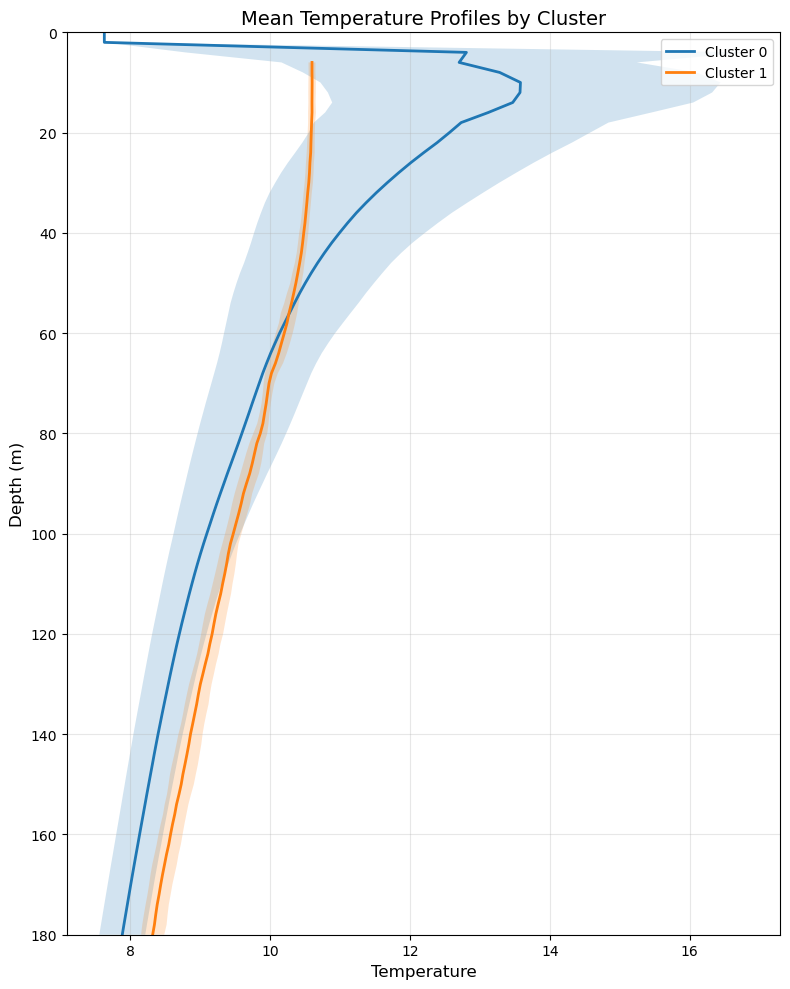

Saved cluster_profiles_temperature.png


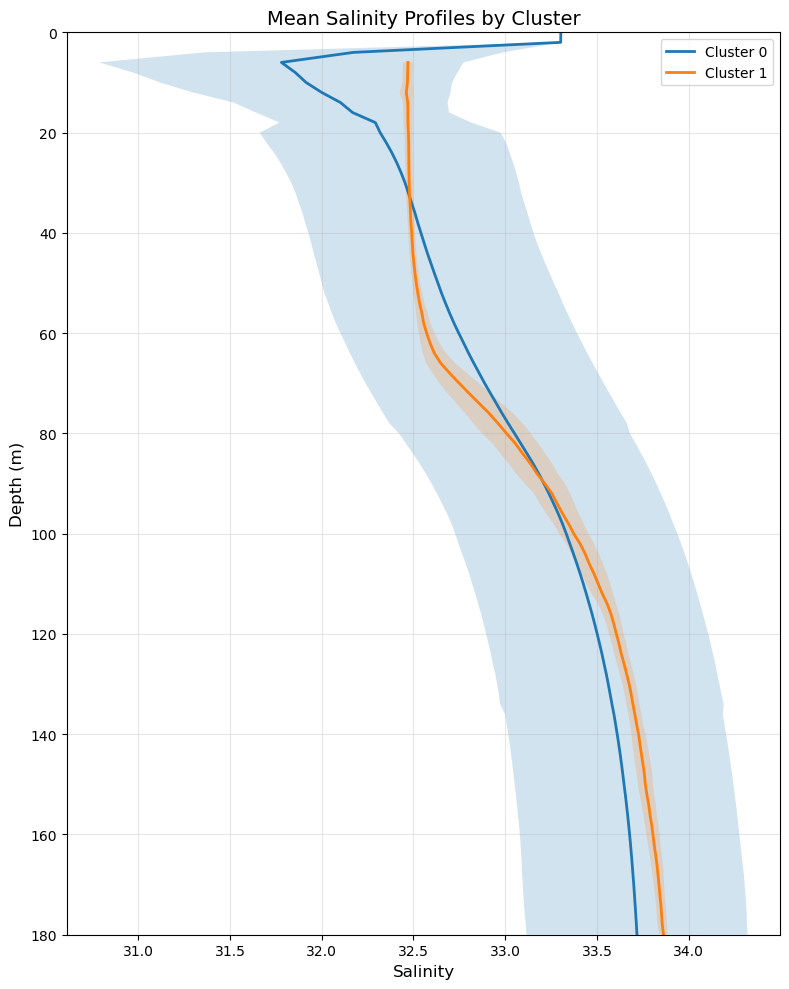

Saved cluster_profiles_salinity.png


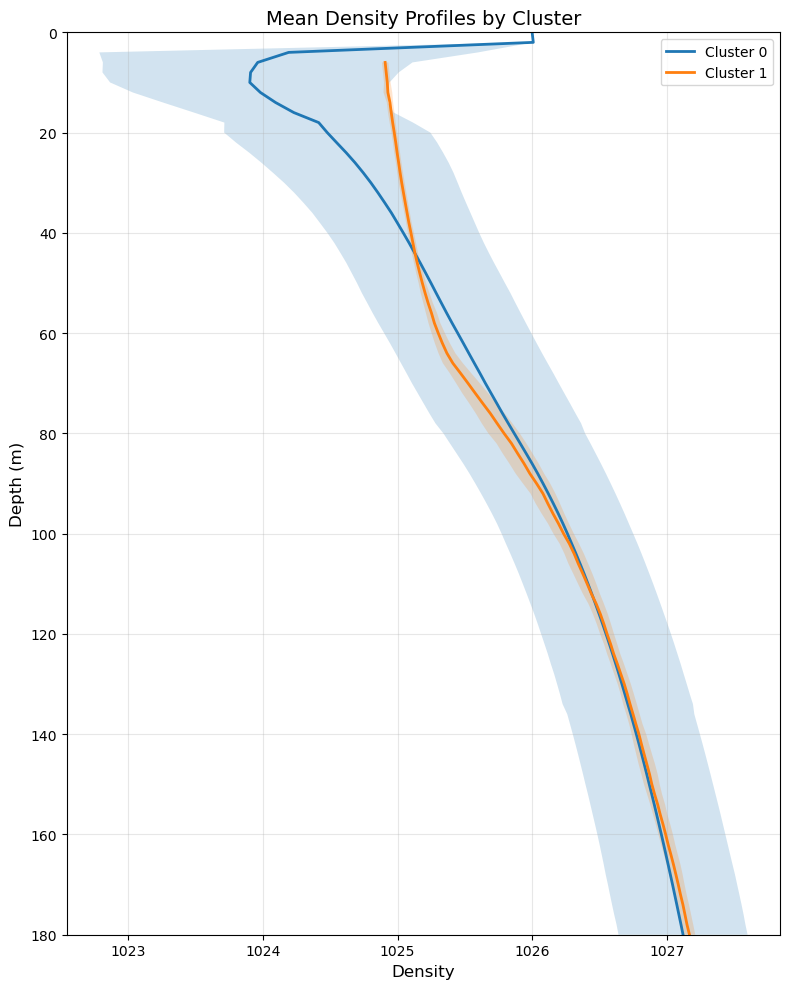

Saved cluster_profiles_density.png


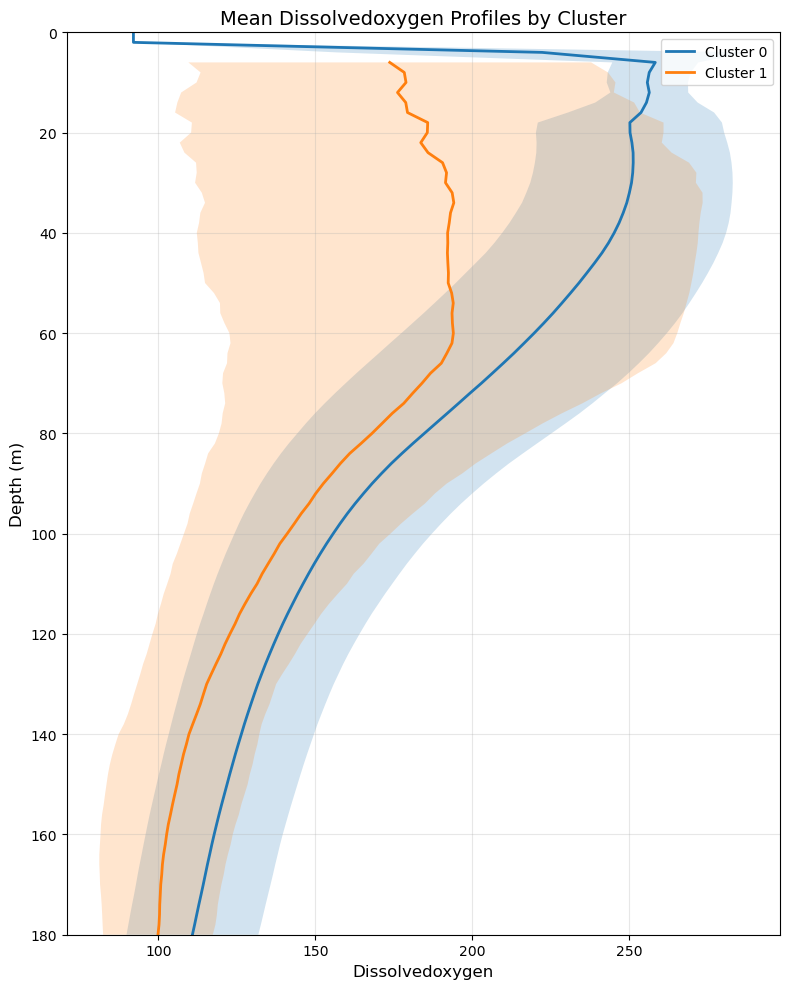

Saved cluster_profiles_dissolvedoxygen.png


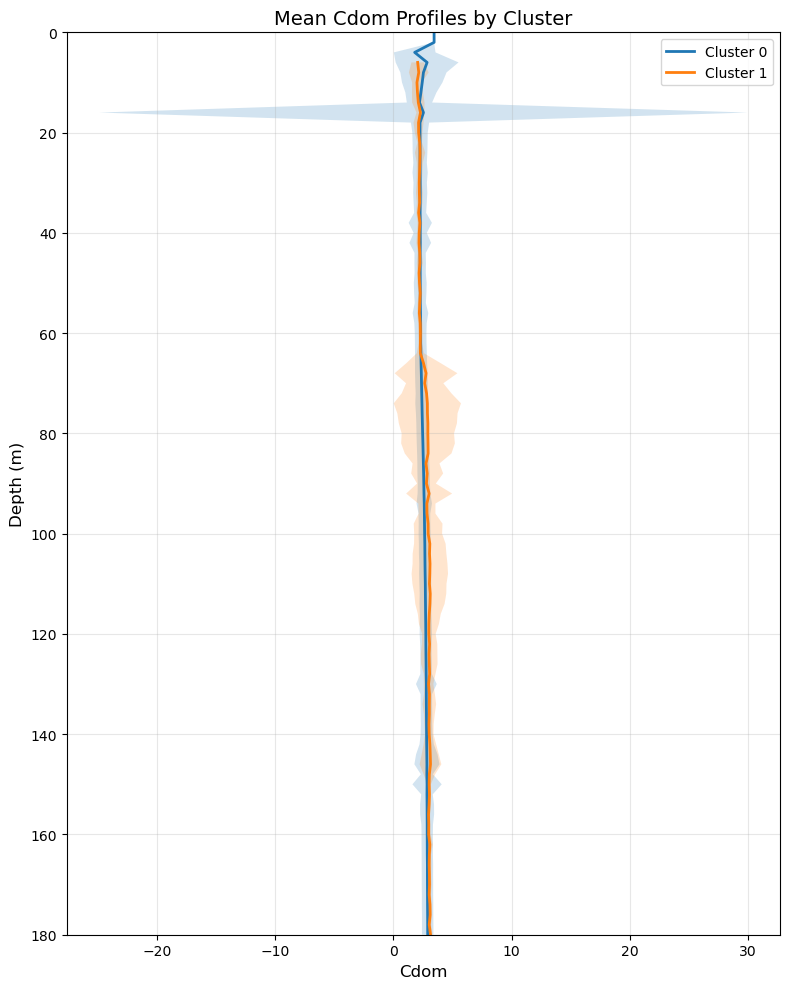

Saved cluster_profiles_cdom.png


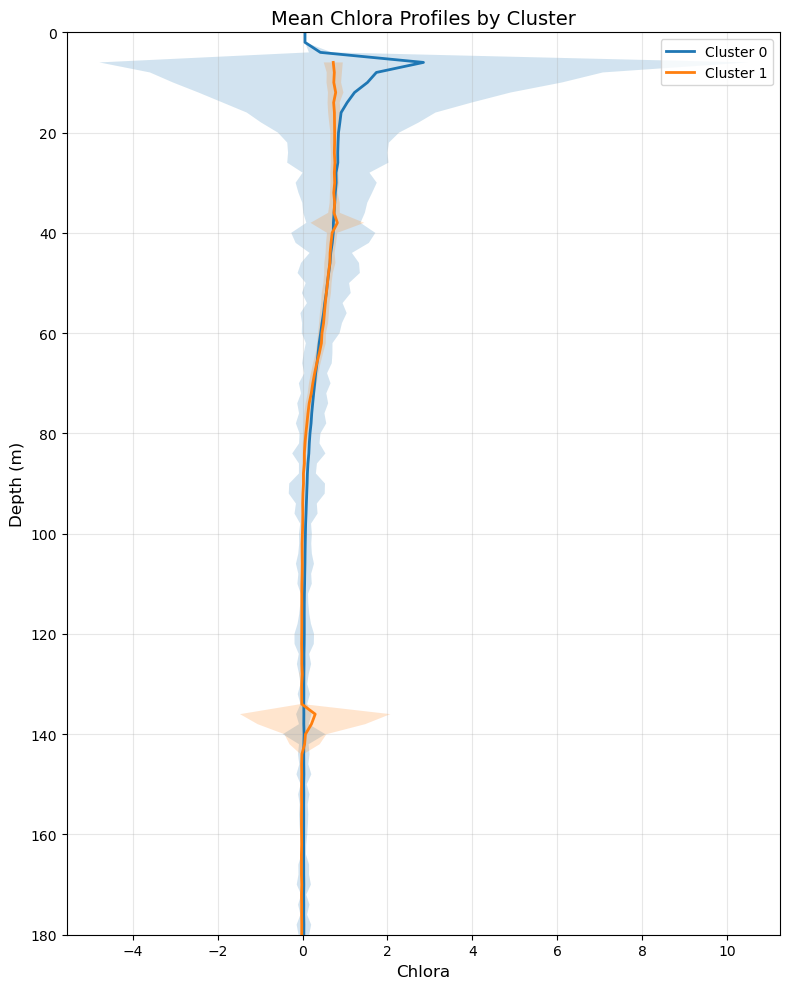

Saved cluster_profiles_chlora.png


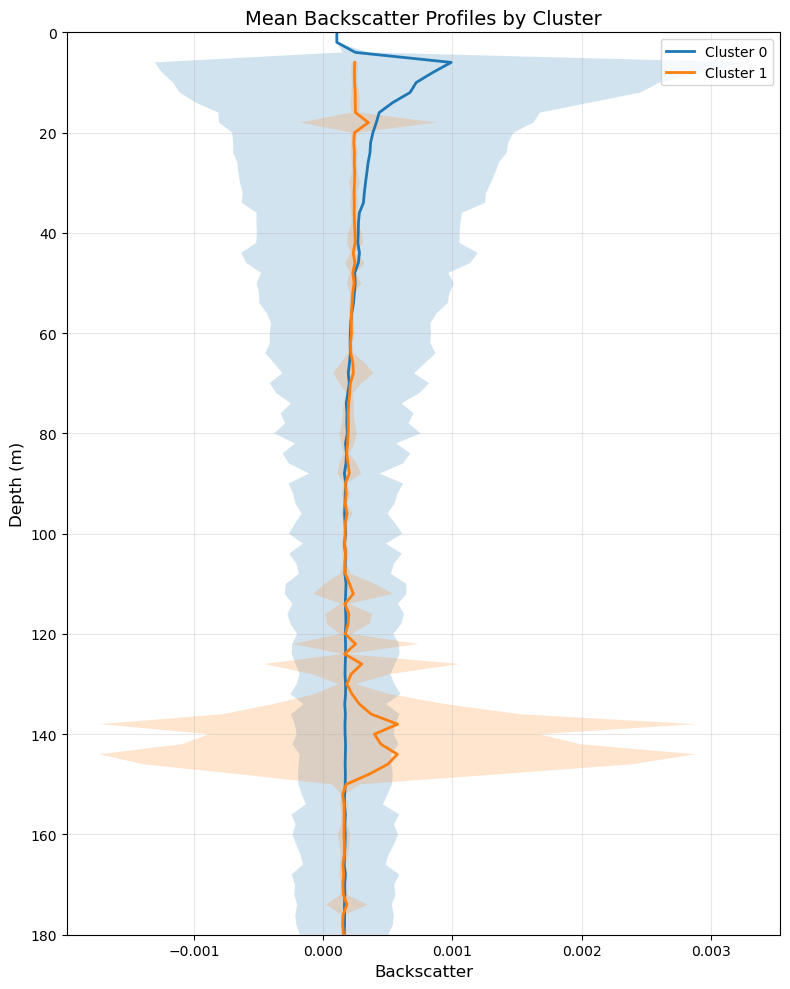

Saved cluster_profiles_backscatter.png


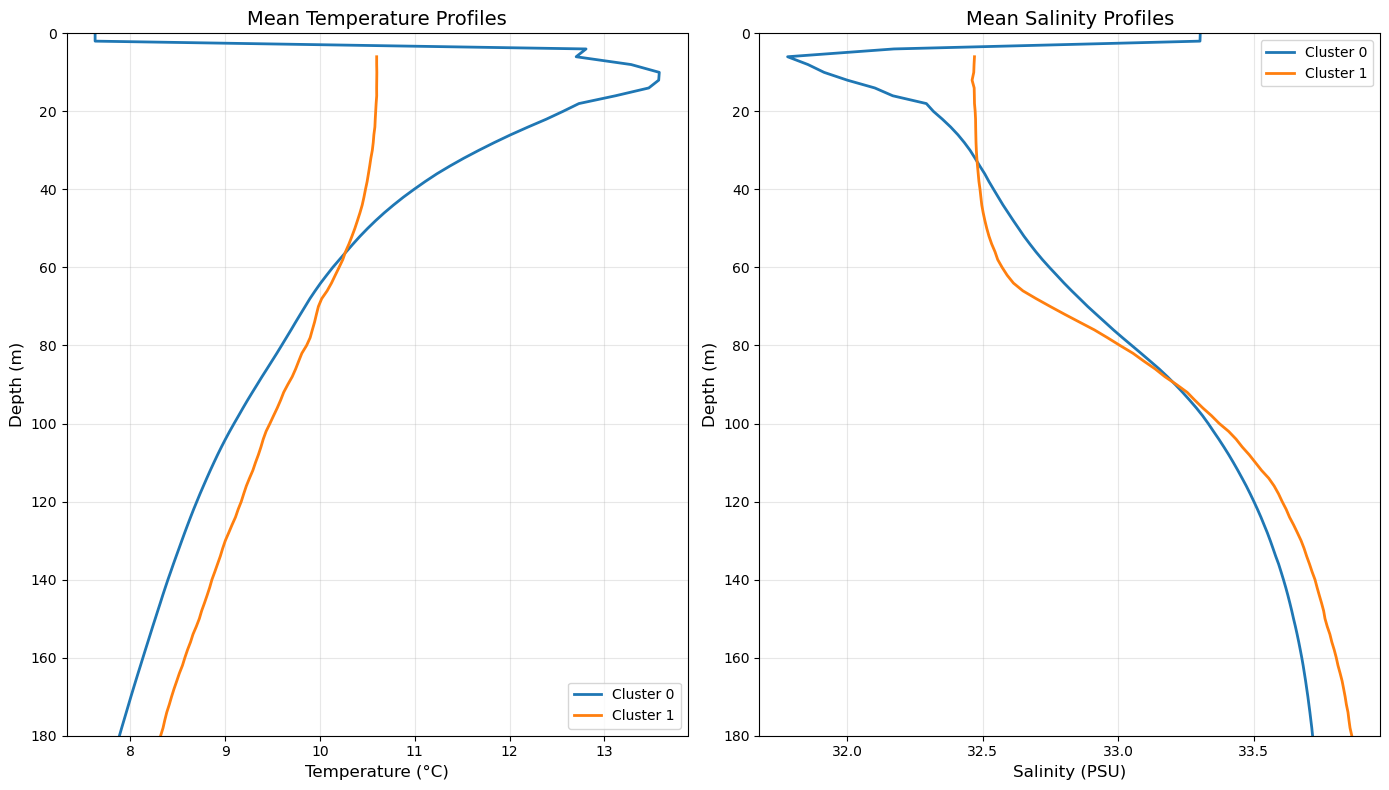


Saved cluster_summary.png

=== Cluster Characterization Summary ===

Cluster 0:
  Size: 8253 profiles (99.6%)
  Date range: 2016-01-01 00:00:00 to 2019-09-27 00:00:00
  Dominant months: Jan, Aug, Oct
  Surface temperature: 7.63°C
  Surface salinity: 33.30 PSU

Cluster 1:
  Size: 32 profiles (0.4%)
  Date range: 2019-04-09 00:00:00 to 2019-04-12 00:00:00
  Dominant months: Apr

Saving cluster characterization...

Saved:
  - cluster_characterization.pkl
  - cluster_profiles_*.png (one per sensor)
  - cluster_summary.png

=== Characterization Complete ===
Water column regimes have been identified and characterized.
Each cluster represents a distinct oceanographic state.


In [18]:
# Module 7: Characterize Water Column Regimes
# Analyzes physical properties of each cluster

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
from pathlib import Path
import pickle

# Load clustering results
print("Loading clustering results...")
profile_index = pd.read_csv('profile_index_clustered.csv')
profile_index['date'] = pd.to_datetime(profile_index['date'])
cluster_labels = np.load('cluster_labels.npy')

with open('clustering_results.pkl', 'rb') as f:
    clustering_results = pickle.load(f)

n_clusters = clustering_results['n_clusters']
print(f"Clusters: {n_clusters}")
print(f"Profiles: {len(profile_index)}")

# Configuration
SENSORS = ['temperature', 'salinity', 'density', 'dissolvedoxygen', 'cdom', 'chlora', 'backscatter']
STANDARD_DEPTHS = np.linspace(0, 180, 91)

# Load profile files
print("\nLoading profile files...")
all_profiles = {}
for sensor in SENSORS:
    profile_files = []
    for year in profile_index['year'].unique():
        redux_dir = Path(f"~/redux{year}").expanduser()
        if redux_dir.exists():
            year_files = sorted(list(redux_dir.glob(f"*_{sensor}_*.nc")))
            profile_files.extend(year_files)
    all_profiles[sensor] = profile_files

def load_and_interpolate_profile(filepath, sensor_name, standard_depths):
    """Load and interpolate a profile."""
    try:
        ds = xr.open_dataset(filepath)
        sensor_data = ds[sensor_name].values
        depth = ds['depth'].values
        
        valid_mask = ~(np.isnan(sensor_data) | np.isnan(depth))
        if not np.any(valid_mask) or len(depth[valid_mask]) < 2:
            return np.full(len(standard_depths), np.nan)
        
        depth_clean = depth[valid_mask]
        data_clean = sensor_data[valid_mask]
        
        sort_idx = np.argsort(depth_clean)
        depth_sorted = depth_clean[sort_idx]
        data_sorted = data_clean[sort_idx]
        
        interp_data = np.interp(standard_depths, depth_sorted, data_sorted, 
                               left=np.nan, right=np.nan)
        
        return interp_data
        
    except Exception:
        return np.full(len(standard_depths), np.nan)

# Compute mean profiles for each cluster
print("\n=== Computing Cluster Mean Profiles ===")

cluster_profiles = {sensor: {i: [] for i in range(n_clusters)} for sensor in SENSORS}

for sensor in SENSORS:
    print(f"Processing {sensor}...")
    sensor_files = all_profiles[sensor]
    
    for idx, cluster in enumerate(cluster_labels):
        if idx < len(sensor_files):
            profile_data = load_and_interpolate_profile(sensor_files[idx], sensor, STANDARD_DEPTHS)
            if not np.all(np.isnan(profile_data)):
                cluster_profiles[sensor][cluster].append(profile_data)

# Calculate statistics
cluster_means = {sensor: {} for sensor in SENSORS}
cluster_stds = {sensor: {} for sensor in SENSORS}

for sensor in SENSORS:
    for cluster in range(n_clusters):
        profiles = cluster_profiles[sensor][cluster]
        if len(profiles) > 0:
            profiles_array = np.array(profiles)
            cluster_means[sensor][cluster] = np.nanmean(profiles_array, axis=0)
            cluster_stds[sensor][cluster] = np.nanstd(profiles_array, axis=0)
        else:
            cluster_means[sensor][cluster] = np.full(len(STANDARD_DEPTHS), np.nan)
            cluster_stds[sensor][cluster] = np.full(len(STANDARD_DEPTHS), np.nan)

# Plot mean profiles for each sensor
print("\n=== Plotting Cluster Characteristics ===")

for sensor in SENSORS:
    fig, ax = plt.subplots(figsize=(8, 10))
    
    for cluster in range(n_clusters):
        mean_profile = cluster_means[sensor][cluster]
        std_profile = cluster_stds[sensor][cluster]
        
        valid = ~np.isnan(mean_profile)
        if np.any(valid):
            ax.plot(mean_profile[valid], STANDARD_DEPTHS[valid], 
                   linewidth=2, label=f'Cluster {cluster}')
            
            # Add shaded std region
            ax.fill_betweenx(STANDARD_DEPTHS[valid],
                            (mean_profile - std_profile)[valid],
                            (mean_profile + std_profile)[valid],
                            alpha=0.2)
    
    ax.set_ylabel('Depth (m)', fontsize=12)
    ax.set_xlabel(f'{sensor.capitalize()}', fontsize=12)
    ax.set_title(f'Mean {sensor.capitalize()} Profiles by Cluster', fontsize=14)
    ax.set_ylim(180, 0)
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'cluster_profiles_{sensor}.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"Saved cluster_profiles_{sensor}.png")

# Create summary comparison plot (temperature and salinity)
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

for cluster in range(n_clusters):
    # Temperature
    temp_mean = cluster_means['temperature'][cluster]
    valid = ~np.isnan(temp_mean)
    if np.any(valid):
        axes[0].plot(temp_mean[valid], STANDARD_DEPTHS[valid], 
                    linewidth=2, label=f'Cluster {cluster}')

    # Salinity
    sal_mean = cluster_means['salinity'][cluster]
    valid = ~np.isnan(sal_mean)
    if np.any(valid):
        axes[1].plot(sal_mean[valid], STANDARD_DEPTHS[valid], 
                    linewidth=2, label=f'Cluster {cluster}')

axes[0].set_ylabel('Depth (m)', fontsize=12)
axes[0].set_xlabel('Temperature (°C)', fontsize=12)
axes[0].set_title('Mean Temperature Profiles', fontsize=14)
axes[0].set_ylim(180, 0)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_ylabel('Depth (m)', fontsize=12)
axes[1].set_xlabel('Salinity (PSU)', fontsize=12)
axes[1].set_title('Mean Salinity Profiles', fontsize=14)
axes[1].set_ylim(180, 0)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('cluster_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nSaved cluster_summary.png")

# Cluster characterization summary
print("\n=== Cluster Characterization Summary ===")

for cluster in range(n_clusters):
    cluster_profiles_idx = profile_index[profile_index['cluster'] == cluster]
    
    print(f"\nCluster {cluster}:")
    print(f"  Size: {len(cluster_profiles_idx)} profiles ({len(cluster_profiles_idx)/len(profile_index)*100:.1f}%)")
    print(f"  Date range: {cluster_profiles_idx['date'].min()} to {cluster_profiles_idx['date'].max()}")
    
    # Seasonal distribution
    months = cluster_profiles_idx['date'].dt.month
    dominant_months = months.value_counts().head(3)
    month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    print(f"  Dominant months: {', '.join([month_names[m-1] for m in dominant_months.index])}")
    
    # Physical characteristics (surface values)
    temp_surface = cluster_means['temperature'][cluster][0]
    sal_surface = cluster_means['salinity'][cluster][0]
    
    if not np.isnan(temp_surface):
        print(f"  Surface temperature: {temp_surface:.2f}°C")
    if not np.isnan(sal_surface):
        print(f"  Surface salinity: {sal_surface:.2f} PSU")

# Save cluster characterization
print("\nSaving cluster characterization...")

characterization = {
    'cluster_means': cluster_means,
    'cluster_stds': cluster_stds,
    'n_clusters': n_clusters,
    'sensors': SENSORS,
    'depths': STANDARD_DEPTHS
}

with open('cluster_characterization.pkl', 'wb') as f:
    pickle.dump(characterization, f)

print("\nSaved:")
print("  - cluster_characterization.pkl")
print("  - cluster_profiles_*.png (one per sensor)")
print("  - cluster_summary.png")

print("\n=== Characterization Complete ===")
print("Water column regimes have been identified and characterized.")
print("Each cluster represents a distinct oceanographic state.")
